# Important Libraries


In [62]:
import pandas as pd 
import seaborn as sns
import numpy as mp
import  matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error ,root_mean_squared_error ,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# Dataset Load

In [63]:
df = pd.read_csv("laptop_price.csv")

In [64]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [65]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


In [66]:
df.shape

(1303, 13)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In this dataset there are 13 columns where most of them are object(string) and only 2 contain flaot and rest of them are int

In [68]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [69]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


# EDA

In [70]:
df.isna().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(0)

# Performing Encoding

In [72]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   int64  
 2   Product           1303 non-null   int64  
 3   TypeName          1303 non-null   int64  
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   int64  
 6   Cpu               1303 non-null   int64  
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   int64  
 9   Gpu               1303 non-null   int64  
 10  OpSys             1303 non-null   int64  
 11  Weight            1303 non-null   int64  
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(11)
memory usage: 132.5 KB


# Data spliting

In [74]:
x = df.drop(['Price_euros','laptop_ID'],axis=1)
y= df['Price_euros']

# Performing Train-Test_Split

In [75]:
xtrain,xtest,ytrain, ytest = train_test_split(x,y,train_size=.20,random_state=42)

# Performing Regressor algorithms , train model and evaluation

# **Linear Regresson**

In [76]:
le = LinearRegression()

In [77]:
model = le.fit(xtrain,ytrain)

print("Training Score in LinearRegression : ", model.score(xtrain,ytrain)*100)
print("Test Score in LionearRegression : ", model.score(xtest,ytest)*100)

# Prediction
y_pred = le.predict(xtest)

Training Score in LinearRegression :  44.39027069748587
Test Score in LionearRegression :  45.2466865830375


# Model Evaluation

In [78]:
#MAE
mae_lr = mean_absolute_error(ytest,y_pred)
print("MAE : ", mae_lr)

#MSE
mse_lr = mean_squared_error(ytest,y_pred)
print("MSE : ", mse_lr)

#RMSE
rmse_lr = root_mean_squared_error(ytest,y_pred)
print("RMSE : ", rmse_lr)

#R2 Score
r2_score_le = r2_score(ytest,y_pred)
print("R2 Score : ", r2_score_le)

MAE :  368.89508801084196
MSE :  268758.1706117764
RMSE :  518.418914211062
R2 Score :  0.452466865830375


## **Decision Tree Regressor**

In [79]:
dt = DecisionTreeRegressor(max_depth=5,min_samples_split=10,min_samples_leaf=2,random_state=42)

In [102]:
model_dt = dt.fit(xtrain,ytrain)

print("Training Score in Decision Tree Regressor: ", model_dt.score(xtrain,ytrain)*100)
print("Test Score in Decision Tree Regressor : ", model_dt.score(xtest,ytest)*100)

# Prediction
y_pred = dt.predict(xtest)

Training Score in Decision Tree Regressor:  77.26630792756679
Test Score in Decision Tree Regressor :  59.21816204356779


# Model Evaluation

In [81]:
#MAE
mae_dt = mean_absolute_error(ytest,y_pred)
print("MAE : ",mae_dt)

#MSE
mse_dt = mean_squared_error(ytest,y_pred)
print("MSE : ", mse_dt)

#RMSE
rmse_dt = root_mean_squared_error(ytest,y_pred)
print("RMSE : ", rmse_dt)

#R2 Score
r2_score_dt= r2_score(ytest,y_pred)
print("R2 Score : ", r2_score_dt)

MAE :  297.7815985215861
MSE :  200178.79246666914
RMSE :  447.4134468996983
R2 Score :  0.5921816204356779


## **Random Forest Regressor**

In [82]:
rf = RandomForestRegressor( n_estimators=500,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-4)

# Treining and Tesing Model

In [103]:
model_rf = rf.fit(xtrain,ytrain)

print("Training Score in Random Forest Regressor: ", model_rf.score(xtrain,ytrain)*100)
print("Test Score in Random Forest Regressor : ", model_rf.score(xtest,ytest)*100)

# Prediction
y_pred = rf.predict(xtest)

Training Score in Random Forest Regressor:  91.18384539489092
Test Score in Random Forest Regressor :  73.23093273256896


# Model Evaluation

In [84]:
#MAE
mae_rf = mean_absolute_error(ytest,y_pred)
print("MAE : ",mae_rf)

#MSE
mse_rf = mean_squared_error(ytest,y_pred)
print("MSE : ", mse_rf)

#RMSE
rmse_rf = root_mean_squared_error(ytest,y_pred)
print("RMSE : ", rmse_rf)

#R2 Score
r2_score_rf= r2_score(ytest,y_pred)
print("R2 Score : ", r2_score_rf)

MAE :  235.99476254675983
MSE :  131396.71553739315
RMSE :  362.4868487785359
R2 Score :  0.7323093273256895


## **XGBoost Regressor**

In [99]:
xg = XGBRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42)

# Treining and Tesing Model

In [104]:
model_xg = xg.fit(xtrain,ytrain)

print("Training Score in XGBoostRegressor : ", model_xg.score(xtrain,ytrain)*100)
print("Test Score in XGBoostRegressor : ", model_xg.score(xtest,ytest)*100)

# Prediction
y_pred = xg.predict(xtest)

Training Score in XGBoostRegressor :  99.71150623090746
Test Score in XGBoostRegressor :  74.10009729288498


# Model Evaluation

In [101]:
#MAE
mae_xg = mean_absolute_error(ytest,y_pred)
print("MAE : ",mae_xg)

#MSE
mse_xg = mean_squared_error(ytest,y_pred)
print("MSE : ", mse_xg)

#RMSE
rmse_xg = root_mean_squared_error(ytest,y_pred)
print("RMSE : ", rmse_xg)

#R2 Score
r2_score_xg= r2_score(ytest,y_pred)
print("R2 Score : ", r2_score_xg)

MAE :  223.53625603621896
MSE :  127130.3969785101
RMSE :  356.55349805956206
R2 Score :  0.7410009729288498


#  Choose Best Model using Ploting

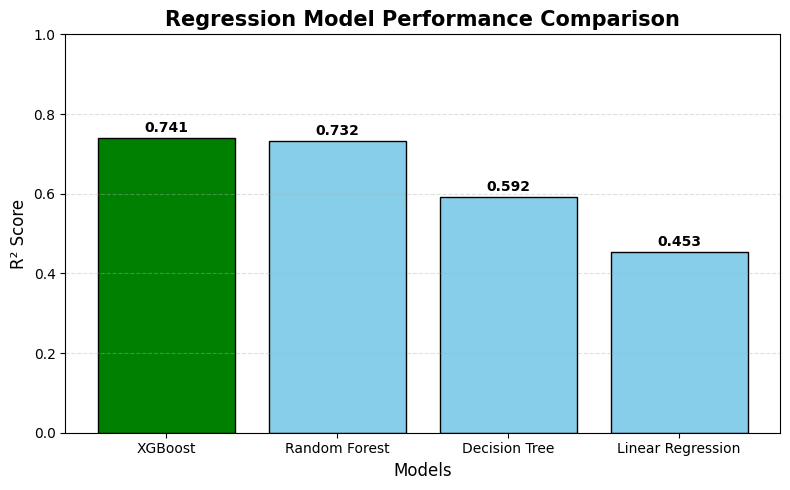

In [ ]:

results = pd.DataFrame({
    "Model":["Linear Regression",
             "Decision Tree",
             "Random Forest",
             "XGBoost"],
    "R2 Score":[0.4525,0.5922,0.7323,0.7410]
})

# Sort by R²
results = results.sort_values("R2 Score", ascending=False)

# Best model = Green, Others = Skyblue
colors = ['green' if model == 'XGBoost' else 'skyblue'
          for model in results['Model']]

plt.figure(figsize=(8,5))

bars = plt.bar(results["Model"], results["R2 Score"],
               color=colors,
               edgecolor='black')

plt.title("Regression Model Performance Comparison", fontsize=15, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0,1)

# Value on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.015,
        f"{bar.get_height():.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()